In [54]:
#Load packages
import numpy as np
import pandas as pd
import time
import os

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,RepeatedStratifiedKFold,GroupKFold,StratifiedGroupKFold,GridSearchCV, RandomizedSearchCV,train_test_split
from sklearn.metrics import roc_curve, precision_recall_curve, PrecisionRecallDisplay, RocCurveDisplay, roc_auc_score, precision_score, recall_score, confusion_matrix,average_precision_score
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.utils import shuffle
from sklearn.calibration import CalibrationDisplay
from xgboost import XGBClassifier
from scipy.stats import randint


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

In [2]:
print(os.cpu_count())

8


In [2]:
subid = 1
windows = [0,1,3,7]
raw_feats_labels = pd.read_csv("/Users/eric/repos/aud/data/ml_labels_alt.csv")
subject_info = pd.read_csv('/Users/eric/repos/aud/data/subject_info.csv')

In [ ]:
nan_df = raw_feats_labels

In [12]:
# NaN testing
subids = subject_info.subid.unique()

for id in subids:
    for window in [0,1,3,7]:
        label_str = "lapse_w"+str(window)
        test_feats_labels = train_feats_labels = shuffle(raw_feats_labels.query("subid != @subid").copy(deep=True).dropna(subset=label_str),random_state=110)
        train_feats = train_feats_labels.drop(labels=['subid','lapse_w0','lapse_w1','lapse_w3','lapse_w7'],axis=1)    
        nan_rows = train_feats.isna().any(axis=1)
        nan_feats = train_feats.loc[nan_rows]
        if nan_feats.shape[0]>0:
            display(nan_feats)
            print("whoa nelly")

In [12]:


lr_output = raw_feats_labels.query("subid==@subid").copy(deep=True)[['subid','day']]
xgb_output = raw_feats_labels.query("subid==@subid").copy(deep=True)[['subid','day']]
for window in windows:
    pred_str = 'w'+str(window)+'_pred'
    act_str = 'w'+str(window)+'_act'
    lr_output[pred_str] = np.nan
    xgb_output[pred_str] = np.nan
    lr_output[act_str] = np.nan
    xgb_output[act_str] = np.nan

# Hyperparameter search grids
lr_hyperparameter_grid = {'penalty':['l1','l2'],'C': [0.001,0.01,0.1,1,10,100,1000]}
xgb_hyperparameter_grid = {'n_estimators':randint(10,500), 'subsample':[0.5,0.75,1],
          'max_depth':randint(1,10),'min_child_weight':randint(1,10)}
gb_hyperparameter_grid = {'n_estimators':randint(10,500),'max_features':['sqrt', None],
          'max_depth':randint(1,5),'min_samples_leaf':randint(1,10)}

folds = StratifiedKFold(n_splits=5,shuffle=True)
# Loop over the windows and fit models

for window in windows[0:1]:
    print(window)
    label_str = "lapse_w"+str(window)
    temp = raw_feats_labels.query("subid==@subid")
    idxs = temp[temp[label_str].notnull()].index.to_numpy()
    train_feats_labels = raw_feats_labels.query("subid != @subid").copy(deep=True).dropna(subset=label_str)
    test_feats_labels = raw_feats_labels.query("subid == @subid").copy(deep=True).dropna(subset=label_str)

    # Training
    train_feats = train_feats_labels.drop(labels=['day','subid','lapse_w0','lapse_w1','lapse_w3','lapse_w7'],axis=1)
    test_feats = test_feats_labels.drop(labels=['day','subid','lapse_w0','lapse_w1','lapse_w3','lapse_w7'],axis=1)
    # Testing 
    train_labels = train_feats_labels[label_str]
    test_labels = test_feats_labels[label_str]

    # LRmodel = LogisticRegression(solver='liblinear')
    # clfLR = GridSearchCV(LRmodel,
    #             param_grid=lr_hyperparameter_grid,
    #             cv=folds, scoring ='f1')
    # clfLR.fit(train_feats.drop(labels='day_of_week_num_0',axis=1),train_labels)
    start = time.time()
    XGBmodel = XGBClassifier(n_jobs=1,objective='binary:logistic',validate_parameters=True)
    clfXGB = RandomizedSearchCV(XGBmodel,
        param_distributions=xgb_hyperparameter_grid,
        cv=folds, n_iter=500, n_jobs=8,
        scoring ='f1',verbose=2)
    clfXGB.fit(train_feats,train_labels)
    elapsed = time.time()-start
    print(elapsed)
    # GBmodel = GradientBoostingClassifier()
    # clfGB = RandomizedSearchCV(GBmodel,
    #     param_distributions=gb_hyperparameter_grid,
    #     cv=folds, n_iter=30, n_jobs=-1,
    #     scoring ='f1',verbose=2)
    # clfGB.fit(train_feats,train_labels)

    pred_str = 'w'+str(window)+'_pred'
    act_str = 'w'+str(window)+'_act'
    # lr_output.loc[idxs,pred_str] = clfLR.best_estimator_.predict_proba(test_feats.drop(labels='day_of_week_num_0',axis=1))[:,1]
    # lr_output.loc[idxs,act_str] = test_labels
    # xgb_output.loc[idxs,pred_str] = clfXGB.best_estimator_.predict_proba(test_feats)[:,1]
    # xgb_output.loc[idxs,act_str] = test_labels
    # xgb_output.loc[idxs,pred_str] = clfGB.best_estimator_.predict_proba(test_feats)[:,1]
    # xgb_output.loc[idxs,act_str] = test_labels

0
Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV] END max_depth=4, min_child_weight=7, n_estimators=128, subsample=0.5; total time=   0.2s
[CV] END max_depth=4, min_child_weight=7, n_estimators=128, subsample=0.5; total time=   0.2s
[CV] END max_depth=4, min_child_weight=7, n_estimators=128, subsample=0.5; total time=   0.3s
[CV] END max_depth=4, min_child_weight=7, n_estimators=128, subsample=0.5; total time=   0.3s
[CV] END max_depth=4, min_child_weight=7, n_estimators=128, subsample=0.5; total time=   0.3s
[CV] END max_depth=7, min_child_weight=5, n_estimators=259, subsample=0.75; total time=   0.4s
[CV] END max_depth=7, min_child_weight=5, n_estimators=259, subsample=0.75; total time=   0.5s
[CV] END max_depth=7, min_child_weight=5, n_estimators=259, subsample=0.75; total time=   0.5s
[CV] END max_depth=3, min_child_weight=8, n_estimators=241, subsample=1; total time=   0.3s
[CV] END max_depth=3, min_child_weight=8, n_estimators=241, subsample=1; total time=   

In [22]:
clfXGB.best_params_


{'max_depth': 8, 'min_child_weight': 8, 'n_estimators': 297, 'subsample': 1}

In [23]:
clfGB.best_params_

{'max_depth': 4,
 'max_features': None,
 'min_samples_leaf': 4,
 'n_estimators': 428}

In [26]:
subid = 1
target_window = 0

raw_feats_labels = pd.read_csv("/Users/eric/repos/aud/data/ml_labels.csv")
feats_labels = raw_feats_labels.query("subid != @subid").copy(deep=True)
feats_labels.head()

,subid,day,day_of_week_num_0,day_of_week_num_1,day_of_week_num_2,day_of_week_num_3,day_of_week_num_4,day_of_week_num_5,day_of_week_num_6,latest_ema_2,latest_ema_3,latest_ema_4,latest_ema_5,latest_ema_6,latest_ema_7,latest_ema_8,latest_ema_9,latest_ema_10,srm_ema_2,srm_ema_3,srm_ema_4,srm_ema_5,srm_ema_6,srm_ema_7,srm_ema_8,srm_ema_9,srm_ema_10,lrm_ema_2,lrm_ema_3,lrm_ema_4,lrm_ema_5,lrm_ema_6,lrm_ema_7,lrm_ema_8,lrm_ema_9,lrm_ema_10,recent_lapse,lapse_w0,lapse_w1,lapse_w3,lapse_w7
89,2,1,0,0,0,0,0,1,0,0.250000,0.083333,0.500000,0.333333,0.3,0.7,0.7,0.7,0.3,0.000000,0.000000,0.333333,0.333333,0.700000,0.700000,0.600000,0.600000,0.100000,0.000000,0.000000,0.333333,0.333333,0.7,0.700000,0.600,0.600,0.100000,False,0,False,False,True
90,2,2,0,0,0,0,0,0,1,0.333333,0.000000,0.333333,0.333333,0.5,0.5,0.5,0.5,0.3,0.125000,0.041667,0.416667,0.333333,0.500000,0.700000,0.650000,0.650000,0.200000,0.125000,0.041667,0.416667,0.333333,0.5,0.700000,0.650,0.650,0.200000,False,0,False,False,True
91,2,3,1,0,0,0,0,0,0,0.083333,0.083333,0.333333,0.083333,0.5,0.5,0.3,0.7,0.2,0.194444,0.027778,0.388889,0.333333,0.500000,0.633333,0.600000,0.600000,0.233333,0.194444,0.027778,0.388889,0.333333,0.5,0.633333,0.600,0.600,0.233333,False,0,False,False,True
92,2,4,0,1,0,0,0,0,0,0.000000,0.000000,0.083333,0.000000,0.5,0.5,0.6,0.7,0.3,0.222222,0.055556,0.388889,0.250000,0.433333,0.566667,0.500000,0.633333,0.266667,0.166667,0.041667,0.375000,0.270833,0.5,0.600000,0.525,0.625,0.225000,False,0,False,False,True
93,2,5,0,0,1,0,0,0,0,0.000000,0.000000,0.333333,0.333333,0.5,0.5,0.4,0.6,0.3,0.138889,0.027778,0.250000,0.138889,0.500000,0.500000,0.466667,0.633333,0.266667,0.133333,0.033333,0.316667,0.216667,0.5,0.580000,0.540,0.640,0.240000,False,0,False,True,True


In [27]:
# Make training set
label_str = "lapse_w"+str(target_window)
print(feats_labels.shape)
feats_labels.dropna(subset=label_str,axis=0)
print(feats_labels.shape)
feats = feats_labels.copy(deep=True).drop(labels=['day','subid','lapse_w0','lapse_w1','lapse_w3','lapse_w7'],axis=1)
labels = feats_labels[label_str]

(12404, 41)
(12404, 41)


In [28]:
feats.head()

,day_of_week_num_0,day_of_week_num_1,day_of_week_num_2,day_of_week_num_3,day_of_week_num_4,day_of_week_num_5,day_of_week_num_6,latest_ema_2,latest_ema_3,latest_ema_4,latest_ema_5,latest_ema_6,latest_ema_7,latest_ema_8,latest_ema_9,latest_ema_10,srm_ema_2,srm_ema_3,srm_ema_4,srm_ema_5,srm_ema_6,srm_ema_7,srm_ema_8,srm_ema_9,srm_ema_10,lrm_ema_2,lrm_ema_3,lrm_ema_4,lrm_ema_5,lrm_ema_6,lrm_ema_7,lrm_ema_8,lrm_ema_9,lrm_ema_10,recent_lapse
89,0,0,0,0,0,1,0,0.250000,0.083333,0.500000,0.333333,0.3,0.7,0.7,0.7,0.3,0.000000,0.000000,0.333333,0.333333,0.700000,0.700000,0.600000,0.600000,0.100000,0.000000,0.000000,0.333333,0.333333,0.7,0.700000,0.600,0.600,0.100000,False
90,0,0,0,0,0,0,1,0.333333,0.000000,0.333333,0.333333,0.5,0.5,0.5,0.5,0.3,0.125000,0.041667,0.416667,0.333333,0.500000,0.700000,0.650000,0.650000,0.200000,0.125000,0.041667,0.416667,0.333333,0.5,0.700000,0.650,0.650,0.200000,False
91,1,0,0,0,0,0,0,0.083333,0.083333,0.333333,0.083333,0.5,0.5,0.3,0.7,0.2,0.194444,0.027778,0.388889,0.333333,0.500000,0.633333,0.600000,0.600000,0.233333,0.194444,0.027778,0.388889,0.333333,0.5,0.633333,0.600,0.600,0.233333,False
92,0,1,0,0,0,0,0,0.000000,0.000000,0.083333,0.000000,0.5,0.5,0.6,0.7,0.3,0.222222,0.055556,0.388889,0.250000,0.433333,0.566667,0.500000,0.633333,0.266667,0.166667,0.041667,0.375000,0.270833,0.5,0.600000,0.525,0.625,0.225000,False
93,0,0,1,0,0,0,0,0.000000,0.000000,0.333333,0.333333,0.5,0.5,0.4,0.6,0.3,0.138889,0.027778,0.250000,0.138889,0.500000,0.500000,0.466667,0.633333,0.266667,0.133333,0.033333,0.316667,0.216667,0.5,0.580000,0.540,0.640,0.240000,False


In [40]:
# split_count=5
# repeats = 10
# rskf = RepeatedStratifiedKFold(n_splits=split_count,n_repeats=repeats,random_state=15)
# spl = rskf.get_n_splits()

hyperparameter_grid = {'penalty':['l1','l2'],'C': [0.001,0.01,0.1,1,10,100,1000]}
LRmodel = LogisticRegression(solver='liblinear')
clfLR = GridSearchCV(LRmodel,
            param_grid=hyperparameter_grid,
            cv=10, scoring ='balanced_accuracy')

clfLR.fit(feats,labels)

GridSearchCV(cv=10, estimator=LogisticRegression(solver='liblinear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2']},
             scoring='balanced_accuracy')

In [44]:
hyperparameter_grid = {'n_estimators':randint(10,500),'max_features':['sqrt', None],
          'max_depth':randint(1,5),'min_samples_leaf':randint(1,10)}
GBmodel = GradientBoostingClassifier()
XGBmodel = XGBClassifier()
# Set up the random search with 4-fold cross validation
clfGB = RandomizedSearchCV(GBmodel,
    param_distributions=hyperparameter_grid,
    cv=5, n_iter=50,
    scoring ='balanced_accuracy',
    n_jobs=-1)
clfGB.fit(feats,labels)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x17645bee0>,
                                        'max_features': ['sqrt', None],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_frozen object at 0x176459bd0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_frozen object at 0x17645a470>},
                   scoring='balanced_accuracy')

In [45]:
hyperparameter_grid = {'n_estimators':randint(10,500),'learning_rate':[0.05,0.1,0.15,0.2],
          'max_depth':randint(1,10),'min_child_weight':randint(1,10)}
XGBmodel = XGBClassifier()
# Set up the random search with 4-fold cross validation
clfXGB = RandomizedSearchCV(XGBmodel,
    param_distributions=hyperparameter_grid,
    cv=5, n_iter=100,
    scoring ='balanced_accuracy')
clfXGB.fit(feats,labels)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           random_state=None, ...),
                   n_iter=100,
                   param_distributions={'learning_rate': [0.05, 0.1, 0.15, 0.2],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x1764bbb20>,
                                        'min_child_weight': <scipy.stats._distn_infrastructure.rv_frozen object at 0x1764bbdf0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_frozen object at 0x176459c60>},
                   scoring='balanced_accuracy')

In [ ]:
yhat = clfXGB.best_estimator_.predict_proba(feats[:,1]

In [19]:
randint(0,50)

In [14]:
test = 1
xgb_hyperparameter_grid = {'n_estimators':[300,400,500,600,700], 'colsample_bytree':[0.5,1],
          'max_depth':[2,3,4,5],'min_child_weight':[2,3,4],'eta':[0.1]}
xgb_hyperparameter_grid_alt = {'n_estimators':np.arange(40,130,10),'eta':[0.1], 'colsample_bytree':[.5,1],
          'max_depth':[1,2],'min_child_weight':[1,2,3]}
a=xgb_hyperparameter_grid if test==0 else xgb_hyperparameter_grid_alt
print(a)

{'n_estimators': array([ 40,  50,  60,  70,  80,  90, 100, 110, 120]), 'eta': [0.1], 'colsample_bytree': [0.5, 1], 'max_depth': [1, 2], 'min_child_weight': [1, 2, 3]}


Split 0
(10506, 37)
Fitting 10 folds for each of 42 candidates, totalling 420 fits
{'colsample_bytree': 0.75, 'eta': 0.2, 'max_depth': 1, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.5}
Split 1
(10509, 37)
Fitting 10 folds for each of 42 candidates, totalling 420 fits
{'colsample_bytree': 0.75, 'eta': 0.2, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 50, 'subsample': 0.5}
Split 2
(10509, 37)
Fitting 10 folds for each of 42 candidates, totalling 420 fits
{'colsample_bytree': 0.75, 'eta': 0.2, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.5}
Split 3
(10507, 37)
Fitting 10 folds for each of 42 candidates, totalling 420 fits
{'colsample_bytree': 0.75, 'eta': 0.2, 'max_depth': 1, 'min_child_weight': 1, 'n_estimators': 50, 'subsample': 0.5}
Split 4
(10517, 37)
Fitting 10 folds for each of 42 candidates, totalling 420 fits
{'colsample_bytree': 0.75, 'eta': 0.2, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 50, 'subsample': 0.5}
Spl

,auc,aucpr,model
0,0.901176,0.780565,logistic regression
1,0.908576,0.796818,gradient boosting
2,0.852880,0.687524,logistic regression
3,0.844454,0.691296,gradient boosting
4,0.916793,0.857445,logistic regression


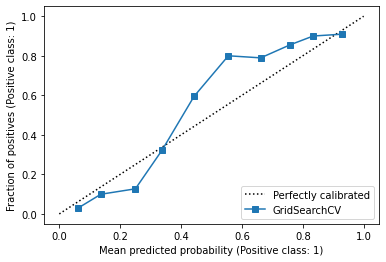

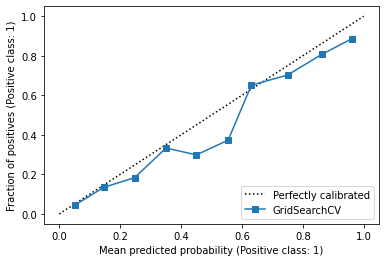

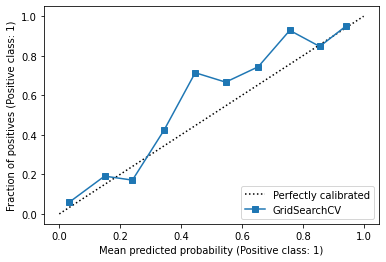

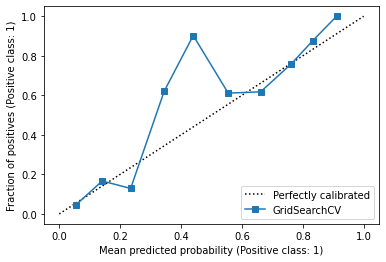

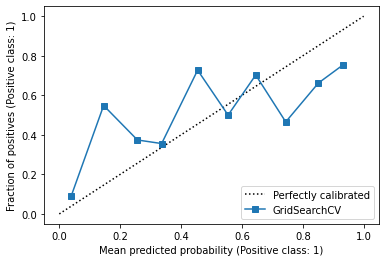

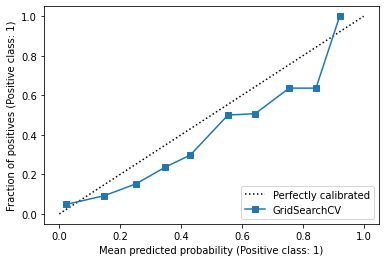

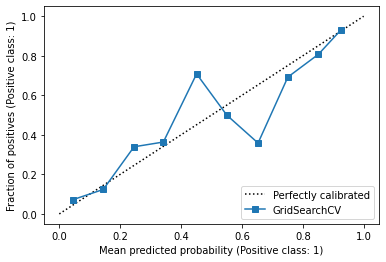

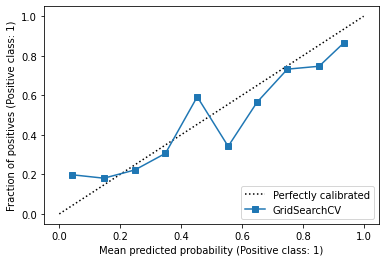

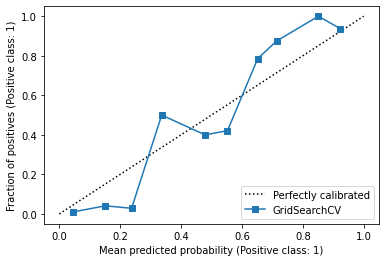

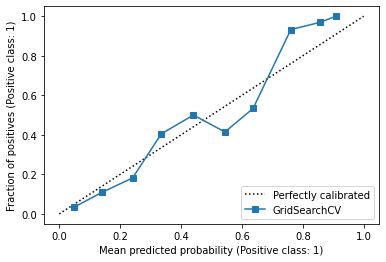

In [83]:
data_store_list=[]
split_count=10
repeats = 1
#rskf = RepeatedStratifiedKFold(n_splits=split_count,n_repeats=repeats,random_state=10)
sgkf = GroupKFold(n_splits=10)
#spl = sgkf.get_n_splits()
#spl = rskf.get_n_splits()
# Define the grid of hyperparameters to search
xgb_hyperparameter_grid = {'n_estimators':[300,400,500,600,700], 'colsample_bytree':[0.5,1],
          'max_depth':[2,3,4,5],'min_child_weight':[2,3,4],'eta':[0.1]}
xgb_hyperparameter_grid_alt = {'n_estimators':[25,50,75,100,125,150,200],'eta':[0.2], 'colsample_bytree':[.75], 'subsample':[0.5],
          'max_depth':[1,2,3],'min_child_weight':[1,3]}
iter_count = 500

target = 'lapse_w7'
temp_df = raw_feats_labels.copy(deep=True).dropna(subset=[target]).reset_index(drop=True)
#current_df = shuffle(temp_df,random_state=15)
current_df = temp_df#.reset_index(drop=True)
Y = current_df[target]
# Consider putting minus_labels back into the drop list
X = current_df.drop(labels=['day','subid','lapse_w0','lapse_w1','lapse_w3','lapse_w7'],axis=1)
G = current_df['subid']
#for i, (train,test) in enumerate(rskf.split(X,Y)):
for i, (train,test) in enumerate(sgkf.split(X,Y,groups=G)):
    #print(test[0:100])
    print("Split {}".format(i))
    x_train = X.loc[train].copy(deep=True)
    g_train = G.loc[train].copy(deep=True)
    y_train = Y.loc[train].copy(deep=True)
    x_test = X.loc[test].copy(deep=True)
    y_test = Y.loc[test].copy(deep=True)
    print(x_train.shape)
    #x_train_reduced, x_train_cv, y_train_reduced, y_train_cv = train_test_split(x_train,y_train,stratify = [0,1],shuffle=True)
    # Logistic regression
    LRmodel = LogisticRegression(penalty=None,max_iter=10000,fit_intercept=True)
    LRclf=LRmodel.fit(x_train,y_train)
    yhat = LRmodel.predict_proba(x_test)[:,1]
    auc = roc_auc_score(y_test,yhat)
    aucpr = average_precision_score(y_test,yhat)
    aucs = {}
    aucprs = {}
    temp_df = pd.DataFrame({'auc':auc,'aucpr':aucpr,
                        'model':"logistic regression"},index=[0])
    data_store_list.append(temp_df)
    # # Gradient boosting
    n_folds = 10
    cv_generator = StratifiedGroupKFold(n_splits=10,shuffle=True)
    XGBmodel = XGBClassifier(n_jobs=1,objective='binary:logistic',validate_parameters=True)
    # #XGBmodel = GradientBoostingClassifier()
    # clfXGB = RandomizedSearchCV(XGBmodel,
    #     param_distributions=xgb_hyperparameter_grid_alt,
    #     cv=n_folds, n_iter=iter_count, n_jobs=8,
    #     scoring ='neg_log_loss',verbose=1)
    clfXGB = GridSearchCV(XGBmodel,
        param_grid=xgb_hyperparameter_grid_alt,
        cv=cv_generator, n_jobs=8,
        scoring ='f1',verbose=1)
    clfXGB.fit(x_train,y_train,groups=g_train)
    print(clfXGB.best_params_)

    CalibrationDisplay.from_estimator(clfXGB,x_test,y_test,n_bins=10)
    yhat = clfXGB.best_estimator_.predict_proba(x_test)[:,1]
    auc = roc_auc_score(y_test,yhat)
    aucpr = average_precision_score(y_test,yhat)
    aucs = {}
    aucprs = {}
    temp_df = pd.DataFrame({'auc':auc,'aucpr':aucpr,
                        'model':"gradient boosting"},index=[0])
    data_store_list.append(temp_df)        

data_store_df = pd.concat(data_store_list,ignore_index=True)
data_store_df.head()

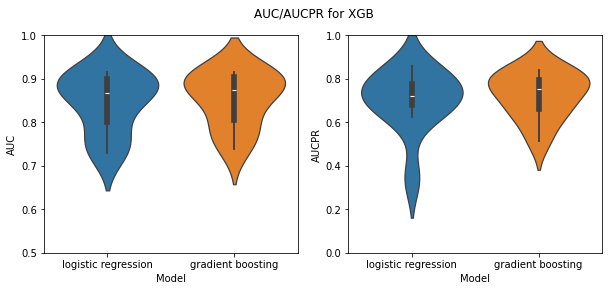

In [84]:
# Active testing
import seaborn as sns
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1,2,figsize=(10,4))
ordering = ['logistic regression','gradient boosting']
ax=axs[0]
sns.violinplot(ax=ax,data=data_store_df,x='model',y='auc',order=ordering,hue='model')
ax.set_ylabel("AUC")
ax.set_xlabel("Model")
ax.set_ylim([.5,1])

ax=axs[1]
sns.violinplot(ax=ax,data=data_store_df,x='model',y='aucpr',order=ordering,hue='model')
ax.set_ylabel("AUCPR")
ax.set_xlabel("Model")
ax.set_ylim([0,1])

fig.suptitle("AUC/AUCPR for XGB")
None

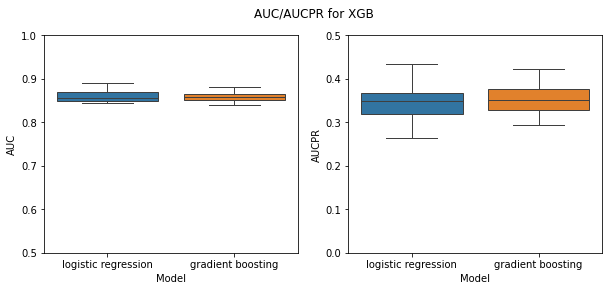

In [58]:
# Original
import seaborn as sns
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1,2,figsize=(10,4))
ordering = ['logistic regression','gradient boosting']
ax=axs[0]
sns.boxplot(ax=ax,data=data_store_df,x='model',y='auc',order=ordering,hue='model')
ax.set_ylabel("AUC")
ax.set_xlabel("Model")
ax.set_ylim([.5,1])

ax=axs[1]
sns.boxplot(ax=ax,data=data_store_df,x='model',y='aucpr',order=ordering,hue='model')
ax.set_ylabel("AUCPR")
ax.set_xlabel("Model")
ax.set_ylim([0,.5])

fig.suptitle("AUC/AUCPR for XGB")
None

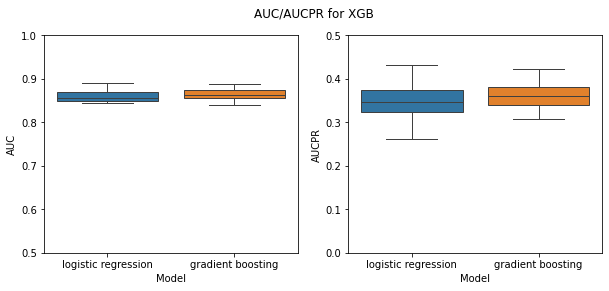

In [55]:
# Alt feature definition
import seaborn as sns
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1,2,figsize=(10,4))
ordering = ['logistic regression','gradient boosting']
ax=axs[0]
sns.boxplot(ax=ax,data=data_store_df,x='model',y='auc',order=ordering,hue='model')
ax.set_ylabel("AUC")
ax.set_xlabel("Model")
ax.set_ylim([.5,1])

ax=axs[1]
sns.boxplot(ax=ax,data=data_store_df,x='model',y='aucpr',order=ordering,hue='model')
ax.set_ylabel("AUCPR")
ax.set_xlabel("Model")
ax.set_ylim([0,.5])

fig.suptitle("AUC/AUCPR for XGB")
None

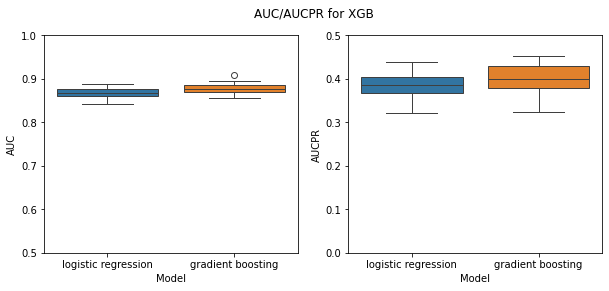

In [52]:
# Alt feature definition - high responsive individuals only
import seaborn as sns
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1,2,figsize=(10,4))
ordering = ['logistic regression','gradient boosting']
ax=axs[0]
sns.boxplot(ax=ax,data=data_store_df,x='model',y='auc',order=ordering,hue='model')
ax.set_ylabel("AUC")
ax.set_xlabel("Model")
ax.set_ylim([.5,1])

ax=axs[1]
sns.boxplot(ax=ax,data=data_store_df,x='model',y='aucpr',order=ordering,hue='model')
ax.set_ylabel("AUCPR")
ax.set_xlabel("Model")
ax.set_ylim([0,.5])

fig.suptitle("AUC/AUCPR for XGB")
None